Loaded 2 expense(s) from previous session.

 **PERSONAL EXPENSE TRACKER**
1. Add Expense
2. View Expenses
3. Generate Report
4. Show Chart
5. Save and Exit


Enter your choice:  4


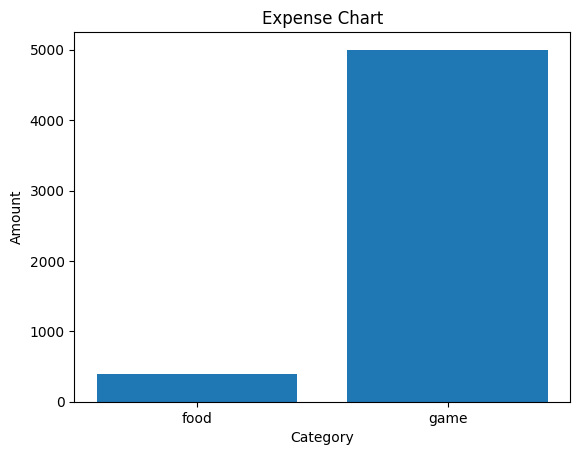


 **PERSONAL EXPENSE TRACKER**
1. Add Expense
2. View Expenses
3. Generate Report
4. Show Chart
5. Save and Exit


In [ ]:
"""  Expense Tracker  """

# importing tools 

import csv
import os
import matplotlib.pyplot as plt
from datetime import datetime

# crea

expenses = []
DATA_FILE = "expenses.csv"


# Add Expense
def add_expense():

    try:
        amount = float(input("Enter amount: "))
        if amount <= 0:
            print("Amount must be greater than zero.")
            return
    except ValueError:
        print("Invalid amount! Please enter a number.")
        return

    category = input("Enter category: ").strip()
    if category == "":
        print("Category cannot be empty.")
        return

    date_input = input("Enter date (DD-MM-YYYY): ").strip()
    try:
        datetime.strptime(date_input, "%d-%m-%Y")
    except ValueError:
        print("Invalid date format! Use DD-MM-YYYY.")
        return

    expense = {
        "amount": amount,
        "category": category,
        "date": date_input
    }

    expenses.append(expense)

    print("Expense added successfully!")


# View Expenses
def view_expenses():

    if len(expenses) == 0:
        print("No expenses found.")
        return

    print("\nDate\t\tCategory\tAmount")

    for expense in expenses:

        print(
            expense["date"],
            "\t",
            expense["category"],
            "\t₹",
            expense["amount"]
        )


# Generate Report
def report():

    if len(expenses) == 0:
        print("No expenses found.")
        return

    total = 0

    for expense in expenses:
        total = total + expense["amount"]

    print("\nTotal Spending = ₹", total)

    category_total = {}

    for expense in expenses:

        category = expense["category"]

        if category in category_total:
            category_total[category] += expense["amount"]
        else:
            category_total[category] = expense["amount"]

    print("\nCategory-wise Spending:")

    for category in category_total:
        print(category, "=", category_total[category])

    # Highest expense
    try:
        highest = max(expenses, key=lambda e: e["amount"])
        print(
            "\nHighest Expense:",
            highest["category"],
            "- ₹", highest["amount"],
            "on", highest["date"]
        )
    except ValueError:
        pass


# Save Expenses
def save_expenses():

    try:
        with open(DATA_FILE, "w", newline="") as file:

            writer = csv.DictWriter(
                file,
                fieldnames=["amount", "category", "date"]
            )

            writer.writeheader()

            writer.writerows(expenses)

        print("Data saved successfully!")

    except PermissionError:
        print("Permission denied! Could not save file.")
    except OSError as e:
        print("Error saving file:", e)


# Load Expenses (runs at program start)
def load_expenses():

    if not os.path.exists(DATA_FILE):
        return

    try:
        with open(DATA_FILE, "r", newline="") as file:

            reader = csv.DictReader(file)

            for row in reader:
                try:
                    row["amount"] = float(row["amount"])
                    expenses.append(row)
                except (ValueError, KeyError):
                    continue

        if len(expenses) > 0:
            print("Loaded", len(expenses), "expense(s) from previous session.")

    except OSError as e:
        print("Could not load previous data:", e)


# Show Chart
def show_chart():

    if len(expenses) == 0:
        print("No expenses to chart.")
        return

    category_total = {}

    for expense in expenses:

        category = expense["category"]

        if category in category_total:
            category_total[category] += expense["amount"]
        else:
            category_total[category] = expense["amount"]

    try:
        categories = list(category_total.keys())
        amounts = list(category_total.values())

        plt.bar(categories, amounts)

        plt.xlabel("Category")
        plt.ylabel("Amount")
        plt.title("Expense Chart")

        plt.show()

    except Exception as e:
        print("Could not display chart:", e)


# Main Menu
load_expenses()

while True:

    print("\n============================")
    print(" **PERSONAL EXPENSE TRACKER**")
    print("============================")

    print("1. Add Expense")
    print("2. View Expenses")
    print("3. Generate Report")
    print("4. Show Chart")
    print("5. Save and Exit")

    choice = input("Enter your choice: ")

    if choice == "1":
        add_expense()

    elif choice == "2":
        view_expenses()

    elif choice == "3":
        report()

    elif choice == "4":
        show_chart()

    elif choice == "5":
        save_expenses()
        print("Thank you!")
        break

    else:
        print("Invalid choice!")